In [82]:
import sys
# Remove any cached version of the module
for key in list(sys.modules.keys()):
    if 'LearnML' in key:
        del sys.modules[key]

In [83]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

# Verify path
print("Path added:", Path.cwd().parent)
#the previous lines is necessary to ensure that the LearnML library is correctly imported and used in the notebook, allowing for testing and experimentation with the regression models and their associated functions.

from LearnML.learn_about.learn_about import learn_about_LinearRegression , learn_about_PolynomialRegression
from LearnML.supervised.regression import LinearRegression, PolynomialRegression
from LearnML.selection.split import train_test_split
from LearnML.metrics.metrics import regression_report



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Path added: /home/mo/Documents/LearnML_Library


Linear Regression is a supervised learning algorithm used for predicting a continuous target variable based on one or more input features. It assumes a linear relationship between the input features and the target variable. The goal of linear regression is to find the best-fitting line (or hyperplane in higher dimensions) that minimizes the difference between the predicted values and the actual values of the target variable.

Key Concepts:
1. Model Representation: The linear regression model can be represented as: y = w1*x1 + w2*x2 + ... + wn*xn + b, where y is the predicted output, x1, x2, ..., xn are the input features, w1, w2, ..., wn are the weights (coefficients), and b is the bias (intercept).
2. Loss Function: The most commonly used loss function for linear regression is Mean Squared Error (MSE), which measures the average squared difference between predicted and actual values.
3. Optimization: The model parameters (weights and bias) are optimized using techniques like Gradient 

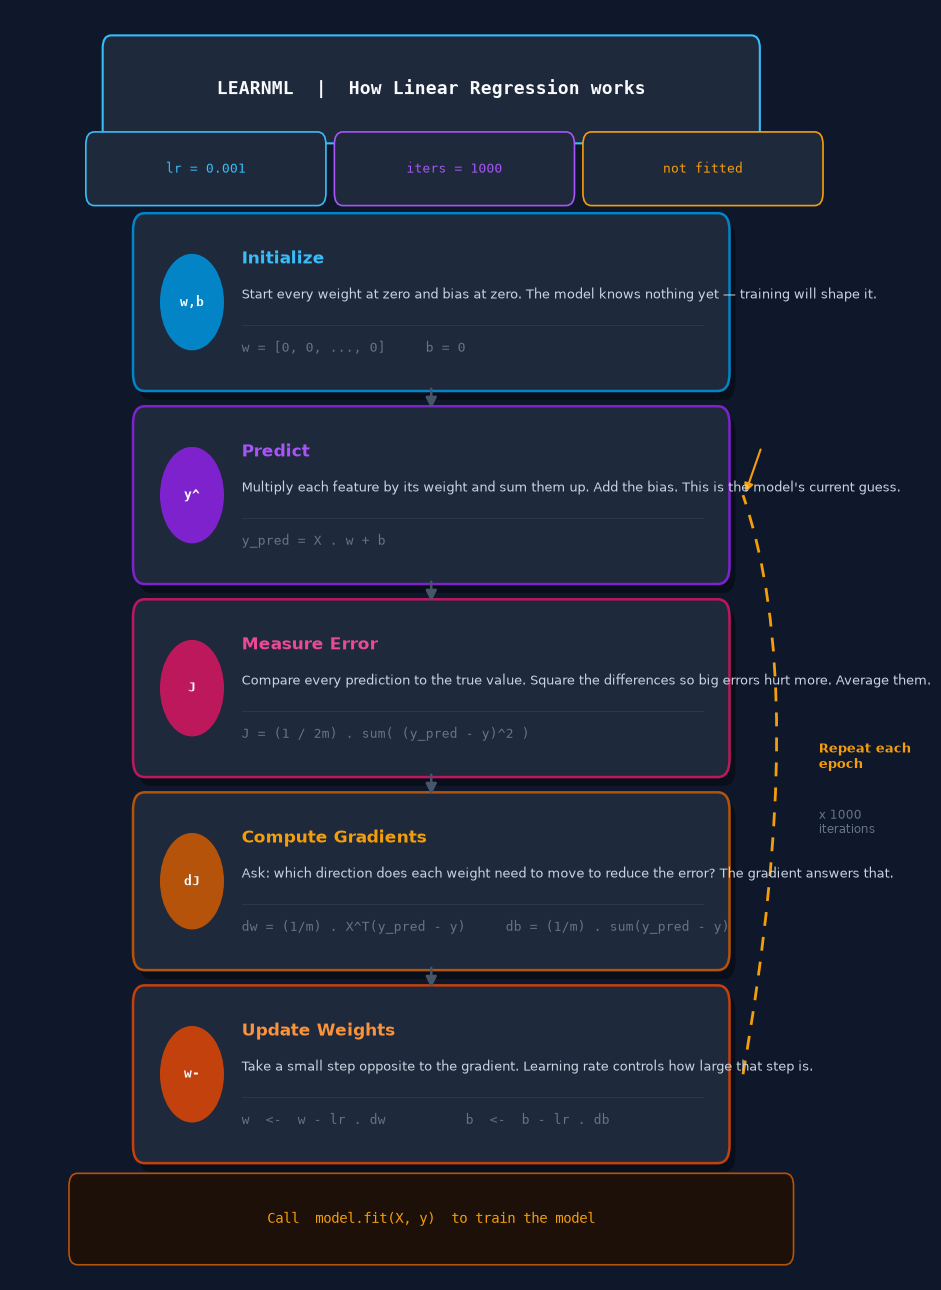

In [84]:
#this function tells the user about the LinearRegression class, including its purpose, usage, and examples. It is a helpful resource for users who want to learn more about linear regression and how to use it in their machine learning projects.
learn_about_LinearRegression()



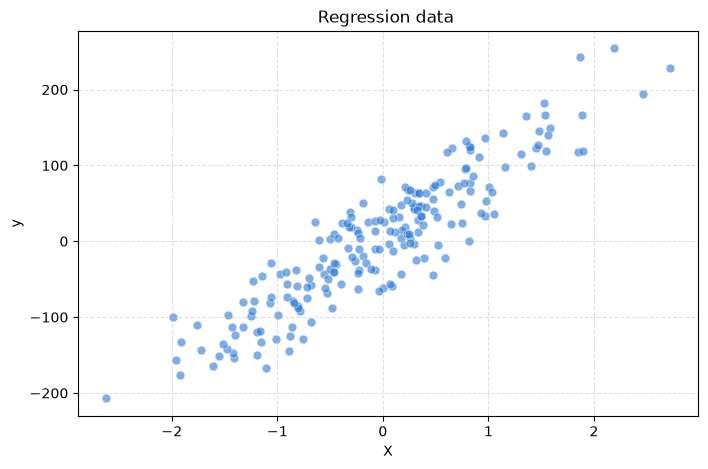

In [85]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=1, noise=35, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="#2a78d6", alpha=0.6, s=40, edgecolors="white", linewidth=0.5)
plt.title("Regression data ")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [86]:
print("X :")
print(X)



X :
[[ 1.85227818]
 [ 0.47359243]
 [-1.23086432]
 [ 0.62566735]
 [-0.07201012]
 [ 0.81252582]
 [-0.18565898]
 [-0.81581028]
 [ 0.06023021]
 [ 0.65655361]
 [ 2.46324211]
 [ 1.0035329 ]
 [-0.26465683]
 [-0.23458713]
 [-0.56228753]
 [ 0.29698467]
 [ 0.08704707]
 [ 1.45353408]
 [-0.97468167]
 [-1.4123037 ]
 [-0.50347565]
 [-0.07710171]
 [ 0.38531738]
 [-1.40185106]
 [-0.07282891]
 [ 0.34115197]
 [ 0.8219025 ]
 [-0.44651495]
 [-0.46947439]
 [ 1.86577451]
 [-1.42474819]
 [-0.60170661]
 [ 0.82254491]
 [-0.46341769]
 [ 0.96337613]
 [ 1.52302986]
 [-0.5297602 ]
 [-1.32045661]
 [-0.99053633]
 [ 0.15372511]
 [-0.01349722]
 [ 1.03099952]
 [ 0.75193303]
 [ 1.47789404]
 [ 0.17457781]
 [-1.24573878]
 [ 0.2088636 ]
 [-0.82068232]
 [ 0.17136828]
 [-0.90802408]
 [ 0.52194157]
 [-1.60748323]
 [ 0.19686124]
 [ 0.00511346]
 [-0.30921238]
 [ 1.14282281]
 [-0.56629773]
 [ 0.97554513]
 [-1.41537074]
 [-0.78325329]
 [ 0.29612028]
 [-1.23695071]
 [ 0.73846658]
 [ 0.01300189]
 [ 0.54256004]
 [-0.68002472]
 [ 0.2

In [87]:
print('y :')
print(y)

y :
[ 1.18033387e+02  7.20906803e+01 -5.30415908e+01  6.52360816e+01
 -1.08123993e+01  1.25296195e+02 -1.99683663e+01 -5.88903215e+01
 -4.20197975e+00  1.22703091e+02  1.94659916e+02  7.17490071e+01
 -2.57966669e+01 -6.33019970e+01 -4.31672614e+01 -3.48815647e+00
 -5.87709190e+01  1.22898685e+02 -4.35015409e+01 -1.53869236e+02
  3.35222945e+00  1.32324665e+01 -2.21626122e+01 -1.23303234e+02
 -3.79350963e+01  6.39000893e+01  7.65248315e+01 -3.00973937e+01
 -4.03528049e+01  2.43349677e+02 -1.12497910e+02 -3.35569458e+01
  1.19888118e+02  9.64845102e+00  3.36742963e+01  1.81996700e+02
 -6.82580345e+01 -1.12742752e+02 -9.77252277e+01  3.22296402e+01
  8.24320484e+01  6.48811727e+01  2.40894631e+01  1.45042894e+02
  4.78996801e+01 -9.83617191e+01  1.88551441e+01 -3.78336372e+01
 -4.33842410e+01 -7.38917893e+01 -4.80260156e+00 -1.64918241e+02
 -4.72786644e+00 -6.21198655e+01  3.83907376e+01  1.42440499e+02
 -2.15519811e+01  5.29509945e+01 -1.47602913e+02 -9.19684952e+01
  4.52915911e+01 -9.1

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

AttributeError: module 'matplotlib.path' has no attribute 'MOVETO'

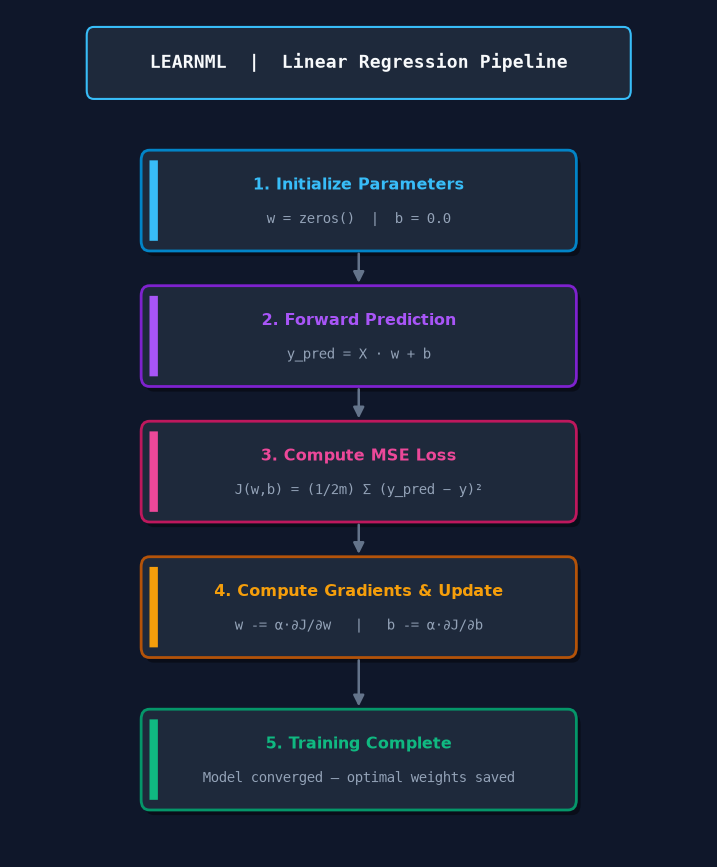

In [93]:
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)


In [ ]:
y_pred = linear_regression_model.predict(X_test)

AttributeError: 'LinearRegression' object has no attribute 'predict'